### Loading model


In [ ]:
#%pip install cobra

In [1]:
import jupyter_utils as ju

In [1]:
import importlib
importlib.reload(ju)

<module 'jupyter_utils' from 'c:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\SoF1-GEM\\Scripts\\jupyter_utils.py'>

In [61]:
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"
model = ju.load_model(base_dir,"Experiment", "250723_iABA974_BLG.sbml")


In [4]:
model

Name,iABA974
Memory address,1dd1c432550
Number of metabolites,1616
Number of reactions,2392
Number of genes,974
Number of groups,0
Objective expression,0.1*BLG_x1_production - 0.1*BLG_x1_production_reverse_f2064 + 1.0*Growth - 1.0*Growth_reverse_699ae
Compartments,"c, p, e"


In [ ]:
model1 = ju.load_model("Reference_GSMs", "iSynCJ816.xml")

In [8]:
model

Name,iSynCJ816
Memory address,29c18e10990
Number of metabolites,928
Number of reactions,1044
Number of genes,816
Number of groups,0
Objective expression,0
Compartments,"cytosol, periplasm, extracellular space, peroxisome/glyoxysome, thylakoid, lysosome, cytochrome complex"


In [64]:
# set reactions bounds for a specific reaction 
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -19.4, 0.0

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -100.0, 0.0

reaction = model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -100.0, 0.0



In [12]:
reaction = model.reactions.get_by_id('EX_glcn_e')
reaction.bounds = -0.0, 0.0
reaction = model.reactions.get_by_id('EX_succ_e')
reaction.bounds = -0.0, 0.0
reaction = model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -100.0, 0.0
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -19.4, 0.0

In [ ]:
model.summary()

0.03


Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.0001486,0,0.00%
cl_e,EX_cl_e,0.0001486,0,0.00%
co2_e,EX_co2_e,1.845,1,100.00%
cobalt2_e,EX_cobalt2_e,7.2E-07,0,0.00%
cu2_e,EX_cu2_e,0.0002023,0,0.00%
fe2_e,EX_fe2_e,0.0004345,0,0.00%
h2_e,EX_h2_e,18.05,0,0.00%
k_e,EX_k_e,0.005571,0,0.00%
mg2_e,EX_mg2_e,0.0002476,0,0.00%
mn2_e,EX_mn2_e,1.974E-05,0,0.00%


# Manual Curation

## Reactions & metabolites 

#### Metabolite reaction summary

In [37]:
metabolite_to_check = model.metabolites.get_by_id('cit_c')
summary = metabolite_to_check.summary()

In [38]:
summary

Percent,Flux,Reaction,Definition
100.00%,0.06836,ACONT,cit_c <=> icit_c
Percent,Flux,Reaction,Definition
100.00%,-0.06836,CITL,cit_c --> ac_c + oaa_c


##### Create a dataframe of this metabolite summary

create a file pathway for this fct

In [12]:
# Extracting the data for file naming
import time
year = time.strftime("%Y")[2:4]
timestr = time.strftime("%m%d")
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.03_Fluxes_values" / "11.03.02_substrate_summary"
filename = f"{year}{timestr}_{metabolite_to_check.id}_summary.xlsx"
file_path = base_dir / filename
ju.metabolite_summary_df(model,summary,file_path)

### Search metabolite

In [41]:
search_word = 'leu__L'
ju.search_metabolite_info(model,search_word)
#search_word = 'caro_c'
#ju.search_metabolite_info(model1,search_word)


🧪 Metabolite: leu__L_c
 - Name       : L-Leucine
 - Formula    : C6H13NO2
 - Charge     : 0
 - Compartment: c
 - Annotations: {'sbo': 'SBO:0000247', 'reactome': ['R-ALL-113580', 'R-ALL-29588', 'R-ALL-351964'], 'kegg.compound': ['C00123', 'C16439', 'D00030'], 'chebi': ['CHEBI:10866', 'CHEBI:13131', 'CHEBI:15603', 'CHEBI:21348', 'CHEBI:25017', 'CHEBI:32619', 'CHEBI:32620', 'CHEBI:32627', 'CHEBI:32628', 'CHEBI:43646', 'CHEBI:43695', 'CHEBI:43733', 'CHEBI:43814', 'CHEBI:57427', 'CHEBI:6260'], 'kegg.drug': 'D00030', 'hmdb': ['HMDB00687', 'HMDB62203', 'HMDB0000687'], 'lipidmaps': 'LMFA01100048', 'biocyc': 'META:LEU', 'metanetx.chemical': ['MNXM140', 'MNXM1106762', 'MNXM1106761'], 'inchikey': 'ROHFNLRQFUQHCH-YFKPBYRVSA-N', 'seed.compound': ['cpd00107', 'cpd15143'], 'sabiork': '69', 'bigg.metabolite': 'leu__L', 'reactome.compound': ['R-ALL-351964', 'R-ALL-113580', 'R-ALL-29588'], 'metacyc': 'LEU'}
 - Related Reactions: LEUTA, LEUt4rpp, LEULEULAPc, LEUabc, AMPTASEAL, BLG_x1_production, Growth,

### Search reaction

In [ ]:
search_word = 'SDPTA'
ju.search_reaction_info(model,search_word)


🔎 Reaction ID: THDPS
 - Name        : Tetrahydrodipicolinate succinylase
 - Equation    : h2o_c + succoa_c + thdp_c --> coa_c + sl2a6o_c
 - Lower Bound : 0.0
 - Upper Bound : 1000.0
 - Annotations : {'sbo': 'SBO:0000176', 'rhea': ['17325', '17326', '17327', '17328'], 'ec-code': '2.3.1.117', 'biocyc': 'META:TETHYDPICSUCC-RXN', 'metanetx.reaction': ['MNXR104806', 'MNXR188900'], 'kegg.reaction': 'R04365', 'seed.reaction': 'rxn03031', 'kegg': 'R04365', 'bigg.reaction': ['THDPS', 'R_THDPS', 'thdps'], 'metacyc': 'TETHYDPICSUCC-RXN'}
 - Genes       : ['AAFOLC_01620']


Show reaction details

In [46]:
ju.print_reaction_details(model, 'DAPDC')


Reaction ID   : DAPDC
Name          : Diaminopimelate decarboxylase
Equation      : 26dap__M_c + h_c --> co2_c + lys__L_c
Lower Bound   : 0.0
Upper Bound   : 1000.0

Metabolites and Stoichiometry:
 - 26dap__M_c     :   -1.0  Name: Meso-2,6-Diaminoheptanedioate                      Charge:   0  Formula: C7H14N2O4
 - h_c            :   -1.0  Name: H+                                                 Charge:   1  Formula: H
 - co2_c          :    1.0  Name: CO2 CO2                                            Charge:   0  Formula: CO2
 - lys__L_c       :    1.0  Name: L-Lysine                                           Charge:   1  Formula: C6H15N2O2

Sum of Charge Balance: 0.0

Associated Genes:
 - AAFOLC_02910


### Check reaction flux

In [29]:
reaction = model.reactions.get_by_id('CYTHYD')
reaction.bounds = -1000.0, 1000.0


In [30]:
objective_rxn ='Growth'
flux = ju.check_reaction_flux(objective_rxn,model, 'NADTRHD')

The reaction 'NADTRHD' has a flux of 8.812 mmol/gDW/hr.


Check reaction fluxes from a specific metabolite

In [37]:
met = 'h2_c'
solution = model.optimize()
active_rxns = ju.get_active_reactions_for_metabolite(model, solution, met)

# Optionally print
for r in active_rxns:
    print(f"{r[1]}: {r[0]}")
    print(f"  Equation: {r[2]}")
    print(f"  Flux: {r[3]:.3f} mmol/gDW/hr\n")

H2tpp: Hydrogen transport diffusion (periplasm)
  Equation: h2_p <=> h2_c
  Flux: 19.400 mmol/gDW/hr

FERHYD: ferredoxin hydrogenase
  Equation: 2.0 fdxrd_c + 2.0 h_c <=> 2.0 fdxo_2_2_c + h2_c
  Flux: -1.114 mmol/gDW/hr

NAD_H2: NAD-linked hydrogenase
  Equation: h_c + nadh_c <=> h2_c + nad_c
  Flux: -18.286 mmol/gDW/hr



### Change reaction bounds

In [74]:
model.reactions.get_by_id('Growth').bounds = -1000.0, 1000.0

### Search in reaction annotation

In [ ]:
for reaction in model.reactions:
    print(reaction.annotation)

### Check reaction by EC-number

In [ ]:
ec_code_wanted = '1.18.6.1'
for reaction in model.reactions:
    ec_code_value = reaction.annotation.get('kegg-id')
    if ec_code_value and ec_code_wanted in ec_code_value:
        print(reaction.id)

### Add Metabolite

In [ ]:
new_metabolite = Metabolite(
    id='lnlncg_c',     # Metabolite ID
    name='Gamma-linolenic acid',     # Metabolite Name
    formula='C18H29O2',         # Chemical Formula
    compartment='c'            # Compartment (e.g., cytoplasm)
)


new_metabolite.annotation = {'kegg.compound':'C03035'}
new_metabolite.charge = -1 

model.add_metabolites([new_metabolite])

print(new_metabolite.formula)

### Add Reaction

In [ ]:
ID = 'CYTHYD'
if ID not in model.reactions:
    reaction = Reaction(ID)
    reaction.name = 'cytochrome-c3 hydrogenase'
    reaction.lower_bound =  -1000.0
    reaction.upper_bound = 1000.0
    reaction.annotation = {'kegg.reaction':' R04015' , 'ec-code': '1.12.2.1'}
    # HAA.annotation = {'biocyc':'CPD-9436', 'chebi':'35194', 'chemspider':'6309', 'inchi':' InChI=1S/C5H8/c1-4-5(2)3/h4H,1-2H2,3H3', 'kegg.compound':'C16521', 'pubchem':'6557'}    
    h2 = model.metabolites.get_by_id('h2_c')
    h = model.metabolites.get_by_id('h_c')  
    n2 = model.metabolites.get_by_id('n2_c')
    pi = model.metabolites.get_by_id('pi_c')
    fdxrd = model.metabolites.get_by_id('ficytc_c')
    fdxo_2_2 = model.metabolites.get_by_id('focytc_c')
    nh3 = model.metabolites.get_by_id('nh3_c')       
    reaction.add_metabolites({fdxrd:-2.,h2:-1.,fdxo_2_2:2.,h:2.})
    
    model.add_reactions([reaction])
    

    print(model.reactions.get_by_id(ID).id)
    print(model.reactions.get_by_id(ID).reaction)

### Add Sink Reaction

In [11]:
model.add_boundary(model.metabolites.get_by_id('hdca_c'), type='sink',lb=0.0, ub=1000)

Reaction identifier,SK_hdca_c
Name,palmitate sink
Memory address,0x2024dfa4710
Stoichiometry,hdca_c --> palmitate -->
GPR,
Lower bound,0.0
Upper bound,1000


### Add annotation to reaction

In [ ]:
reaction = copy_of_model.reactions.get_by_id('LINO_6_DESA')
reaction.name = 'Δ6-Desaturation of Linoleoyl-CoA'
reaction.annotation["kegg.reaction"] = "R00878"
reaction.annotation["ec-code"] = "5.3.1.5"
#reaction.annotation["metanetx.reaction"] = "MNXR95442"

print(reaction.annotation)

### Remove reaction

In [ ]:
reaction_id = "ACACDC"
model.remove_reactions([reaction_id])
# Verify the removal
if reaction_id not in model.reactions:
    print(f"Reaction {reaction_id} has been successfully removed.")
else:
    print(f"Failed to remove reaction {reaction_id}.")

## Genes

### Search gene

In [4]:
gene_id ='AAFOLC_01061'
ju.print_gene_reaction_info(model, gene_id)

Gene 'AAFOLC_01061' not found in the model.


In [10]:
for gene in model.genes:
    print(gene.annotation)

{'sbo': 'SBO:0000243', 'asap': 'ABE-0008389', 'ecogene': 'EG10408', 'ncbigene': '947022', 'ncbigi': '16130476', 'refseq_locus_tag': 'b2551', 'refseq_name': 'glyA', 'refseq_synonym': ['ECK2548', 'JW2535'], 'uniprot': 'P0A825'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0002954', 'ecogene': 'EG13690', 'ncbigene': '944955', 'ncbigi': '16128838', 'refseq_locus_tag': 'b0870', 'refseq_name': 'ltaE', 'refseq_synonym': ['ltaA', 'JW0854', 'ECK0861', 'ybjU'], 'uniprot': 'P75823'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0011010', 'ecogene': 'EG10188', 'ncbigene': '947880', 'ncbigi': '16131246', 'refseq_locus_tag': 'b3368', 'refseq_name': 'cysG', 'refseq_synonym': ['JW3331', 'ECK3356'], 'uniprot': 'P0AEA8'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0008034', 'ecogene': 'EG12189', 'ncbigene': '946908', 'ncbigi': '16130361', 'refseq_locus_tag': 'b2436', 'refseq_name': 'hemF', 'refseq_synonym': ['JW2429', 'ECK2431', 'sec', 'popB'], 'uniprot': 'P36553'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0000027', 'ecogene': 'EG11556

### Add gene

In [5]:
if gene_id not in model.genes:
    new_gene = Gene(id=gene_id)
    model.genes.append(new_gene)
else:
    new_gene = model.genes.get_by_id(gene_id)

Add gene to specific reaction

In [ ]:
reaction = model.reactions.get_by_id('CYTHYD')
#for single gene
#reaction.gene_reaction_rule = gene_id

genes_list = ['AAFOLC_02505','AAFOLC_02510']

# Assign genes using "or" (if any of these genes can catalyze the reaction)
#reaction.gene_reaction_rule = ' or '.join(genes_list)

# If all genes are required together, use " and " instead
reaction.gene_reaction_rule = ' and '.join(genes_list)

# Check assigned genes
print(reaction.genes)
reaction.genes

### Add annotation to gene

In [ ]:
gene = model.genes.get_by_id("AAFOLC_01125")
# Add annotations
gene.annotation["uniprot"] = "Q89CN4"

# Verify the annotation
print(gene.annotation)

## Run pFBA 

In [62]:
from cobra.flux_analysis import pfba
model.objective = "Growth"
solution = model.optimize()
# Perform parsimonious FBA (optional, to minimize overall flux)
pfba_solution = pfba(model)
pfba_fluxes = pfba_solution.fluxes
print(pfba_solution.fluxes)

# Print the flux through the sink reaction for 3PG
print(f"Flux through the objective reaction: {fba_solution.fluxes['Growth']}")

EX_25dkglcn_e       0.000000
EX_2ameph_e         0.000000
EX_2m35mdntha_e     0.000000
EX_2pglyc_e         0.000000
EX_34dhbz_e         0.000000
                      ...   
FACOAE1836Z9Z12Z    0.000016
NIT                 0.000000
FERHYD             -0.457068
CYTHYD              0.000000
Growth              0.044474
Name: fluxes, Length: 2389, dtype: float64
Flux through the objective reaction: 0.04447377605182415


find essential reaction

In [63]:
essential = pfba_fluxes[(pfba_fluxes != 0)]
essential

EX_ca2_e           -0.000220
EX_cl_e            -0.000220
EX_co2_e           -2.124340
EX_cobalt2_e       -0.000001
EX_cu2_e           -0.000300
                      ...   
OLEO_12_DESA        0.000279
LINO_6_DESA         0.000016
FACOAE1836Z9Z12Z    0.000016
FERHYD             -0.457068
Growth              0.044474
Name: fluxes, Length: 474, dtype: float64

#### Show the fluxes with a detailed description of the reaction

In [ ]:
significant_reactions = [
    [
        model.reactions[RctIdx].name, 
        solution.to_frame().iloc[RctIdx].name, 
        model.reactions[RctIdx].reaction, 
        round(solution.fluxes[RctIdx], 2)
    ]
    for RctIdx in np.where(np.abs(solution.fluxes) > 3)[0]
]

# Create a DataFrame for better visualization
df = pd.DataFrame(significant_reactions, columns=["Reaction Name", "Reaction ID", "Reaction Equation", "Flux"])

# Print the DataFrame
df

C:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\Temp\ipykernel_1316\1631945521.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round(solution.fluxes[RctIdx], 2)


,Reaction Name,Reaction ID,Reaction Equation,Flux
0,EX_h2_e,EX_h2_e,h2_e <--,-18.78
1,EX_h2o_e,EX_h2o_e,h2o_e <=>,17.54
2,EX_o2_e,EX_o2_e,o2_e <--,-6.92
3,ATP synthase (four protons for one ATP) (perip...,ATPS4rpp,adp_c + 4.0 h_p + pi_c <=> atp_c + h2o_c + 3.0...,20.78
4,Cytochrome oxidase bd (ubiquinol-8: 2 protons)...,CYTBDpp,2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_...,13.85
5,Glyceraldehyde-3-phosphate dehydrogenase,GAPD,g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c,-3.72
6,Bidirectional [NiFe] Hydrogenase,H2ASE_syn,h_c + nadph_c <=> h2_c + nadp_c,-18.78
7,H2O transport via diffusion,H2Ot,h2o_e <=> h2o_c,-17.73
8,Hydrogen transport via diffusion (extracellula...,H2tex,h2_e <=> h2_p,18.78
9,Hydrogen transport diffusion (periplasm),H2tpp,h2_p <=> h2_c,18.78


## Mass and charge balance

### Read excel files

In [55]:
# Base directory path
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"

# Correct path construction using '/' operator
file_path = base_dir / "Manual_curation" / "Modified reactions.xlsx"
file_path_1 = base_dir / "Manual_curation" / "Modified formula.xlsx"
file_path_2 = base_dir / "Manual_curation" / "Manually modified reactions.xlsx"

# Read Excel files into DataFrames
excel_data_charge = pd.read_excel(file_path)
excel_data_formula = pd.read_excel(file_path_1)
excel_data_Manualcuration = pd.read_excel(file_path_2)

### Check number of unbalanced reactions

In [ ]:
ju.check_model_mass_balance(model)

5
Reaction ID: DHNAOT, Charge Balance: {'charge': 2.0}
Reaction ID: HDECH, Charge Balance: {'charge': 2.0}
Reaction ID: MECDPDH4E, Charge Balance: {'charge': -1.0}
Reaction ID: P9DH, Charge Balance: {'charge': 4.0}
Reaction ID: THZSN_1, Charge Balance: {'H': -1.0}


reaction details

In [50]:
ju.print_reaction_details(model, 'HDECH')


Reaction ID   : HDECH
Name          : 
Equation      : 1hdecg3p_c + h2o_c <=> glyc3p_c + 3.0 h_c + hdcea_c
Lower Bound   : -1000.0
Upper Bound   : 1000.0

Metabolites and Stoichiometry:
 - 1hdecg3p_c     :   -1.0  Name: 1-hexadecanoyl-sn-glycerol 3-phosphate             Charge:  -2  Formula: C19H37O7P
 - h2o_c          :   -1.0  Name: H2O H2O                                            Charge:   0  Formula: H2O
 - glyc3p_c       :    1.0  Name: Glycerol 3-phosphate                               Charge:  -2  Formula: C3H7O6P
 - h_c            :    3.0  Name: H+                                                 Charge:   1  Formula: H
 - hdcea_c        :    1.0  Name: Hexadecenoate (n-C16:1)                            Charge:  -1  Formula: C16H29O2

Sum of Charge Balance: 2.0

Associated Genes:
 - None


balance reaction

In [38]:
reaction = model.reactions.get_by_id('NIT')
metabolite_to_add = 'h2_c'
reaction.add_metabolites({metabolite_to_add: 1.0})
reaction

Reaction identifier,NIT
Name,nitrogenase
Memory address,0x2a126242750
Stoichiometry,16.0 atp_c + 8.0 fdxrd_c + 16.0 h2o_c + n2_c <=> 16.0 adp_c + 8.0 fdxo_2_2_c + h2_c + 6.0 h_c + 2.0 nh4_c + 16.0 pi_c 16.0 ATP C10H12N5O13P3 + 8.0 Reduced ferredoxin + 16.0 H2O H2O + Nitrogen <=> 16.0 ADP C10H12N5O10P2 + 8.0 Oxidized ferredoxin + Hydrogen + 6.0 H+ + 2.0 Ammonium + 16.0 Phosphate
GPR,AAFOLC_05260 or AAFOLC_05265 or AAFOLC_05270 or AAFOLC_05275 or AAFOLC_05280 or AAFOLC_05285 or...
Lower bound,-1000.0
Upper bound,1000.0


Add modification to Excel file

In [ ]:
modification =f'{metabolite_to_add} was added'
# Create a new row with the modification information
new_row = {'reaction ': reaction_id_to_check, 'modification': modification}
# Concatenate the new row to the DataFrame
excel_data_Manualcuration = pd.concat([excel_data_Manualcuration, pd.DataFrame([new_row])], ignore_index=True)

### Remove metabolite

In [46]:
reaction = copy_of_model.reactions.get_by_id('Growth')
metabolite_to_add = 'pe161_p'
reaction.subtract_metabolites({metabolite_to_add: -0.02106})
print(reaction.reaction)

0.000223 10fthf_c + 0.000223 2dmmql8_c + 0.000223 5mthf_c + 0.000279 accoa_c + 0.8168723181883314 ala__L_c + 0.000223 amet_c + 0.03001579312991268 arab__L_c + 0.2557979323259868 arg__L_c + 0.2529593526847482 asn__L_c + 0.2529593526847482 asp__L_c + 37.86 atp_c + 0.004952 ca2_c + 0.000223 chor_c + 0.004952 cl_c + 0.002944 clpn160_p + 0.00229 clpn161_p + 0.00118 clpn181_p + 0.000168 coa_c + 2.4e-05 cobalt2_c + 0.010737250405651103 ctp_c + 0.006744 cu2_c + 0.037472225353906465 cys__L_c + 0.014832979735072188 datp_c + 0.0154992827580827 dctp_c + 0.02400546922059191 dgtp_c + 0.013367475433835764 dttp_c + 0.000223 fad_c + 0.006388 fe2_c + 0.007428 fe3_c + 0.6445556055168562 fru_c + 0.005772 gal_c + 0.11736684160157697 glc__D_c + 0.2753206379465721 gln__L_c + 0.275320637946572 glu__L_c + 0.6379660350235106 gly_c + 0.01659016153669234 gtp_c + 37.86 h2o_c + 0.000223 hemeO_c + 0.049934570136758984 hexadecacid_c + 0.007033277906537638 hexedecacid_c + 0.09352200626083922 his__L_c + 0.2450643067545

Add modification to Excel file

In [217]:
modification =f'{metabolite_to_add} was removed'
# Create a new row with the modification information
new_row = {'reaction ': reaction_id_to_check, 'modification': modification}
# Concatenate the new row to the DataFrame
excel_data_Manualcuration = pd.concat([excel_data_Manualcuration, pd.DataFrame([new_row])], ignore_index=True)

### Change charge of metabolite

In [80]:
metabolite_id = 'fdxrd_c'
if metabolite_id in model.metabolites:
    metabolite = model.metabolites.get_by_id(metabolite_id)
    initial_charge = metabolite.charge  # Store the initial charge for reference
    metabolite.charge = -2
    metabolite.compartment = 'c'
    
    print(list(metabolite.reactions))  
    # Print information about the modified metabolite
    print(f"Modified metabolite: {metabolite.id}")
    print(f"Updated charge: {metabolite.charge}")
    print(f"compartment: {metabolite.compartment}")
else:
    print("Metabolite not found in the model.")

[<Reaction MECDPDH3_syn at 0x1c8cadaa450>, <Reaction MECDPDH4E at 0x1c8cadab890>, <Reaction COCO2 at 0x1c8ca75c0d0>, <Reaction FNOR at 0x1c8ca58bb10>, <Reaction GLUSfx at 0x1c8caa89f10>, <Reaction NOR_syn_1 at 0x1c8caef1110>, <Reaction NIT at 0x1c8cb4bf910>, <Reaction HMEDS at 0x1c8cac16350>, <Reaction THZSN_1 at 0x1c8cb2fb350>]
Modified metabolite: fdxrd_c
Updated charge: -2
compartment: c


#### Add to excel file

In [155]:
# Create a dictionary containing information about the modified reaction
new_row = {'Reaction': reaction_id_to_check, 'metabolite changed': metabolite_id, 'initial charge': initial_charge, 'New charge': metabolite.charge}
excel_data_charge = pd.concat([excel_data_charge, pd.DataFrame([new_row])], ignore_index=True)
excel_data_charge

,Reaction,metabolite changed,initial charge,New charge
0,2AGPG161tipp,2agpg161_c,0,-1
1,3HACPH,r3hbACP_c,0,-1
2,3HAD140,tmrs2eACP_c,0,-1
3,4HOXPACt2pp_1,4hoxpac_p,0,-1
4,4OXPTNtpp,4oxptn_p,0,-1
5,4OXPTNtex,4oxptn_e,0,-1
6,4hoxpactex,4hoxpac_e,0,-1
7,6ATHAtexi,6atha_e,0,-1
8,AADa,aad_c,0,-1
9,ACLS_b,hethmpp_c,-1,-2


### Change formula of metabolite

In [97]:
metabolite_id = 'fdxrd_c'
metabolite = model.metabolites.get_by_id(metabolite_id)
initial_formula = metabolite.formula
metabolite.formula = 'Fe8S8'

#### Add to excel file

In [186]:
new_row_1 = {
    'Reaction': reaction_id_to_check,        # ID of the reaction associated with the metabolite change
    'metabolite changed': metabolite_id,     # ID of the metabolite that was changed
    'initial formula': initial_formula,      # Initial formula of the metabolite
    'New formula': metabolite.formula        # New formula of the metabolite after modification
}
excel_data_formula = pd.concat([excel_data_formula, pd.DataFrame([new_row_1])], ignore_index=False)

excel_data_formula = excel_data_formula.reset_index(drop=True)


In [ ]:
excel_data_formula

## Save updated files

#### Save Excel

In [264]:
# Save the updated DataFrame to the Excel file
excel_data_charge.to_excel(file_path, index=False)
excel_data_formula.to_excel(file_path_1, index=False)
excel_data_Manualcuration.to_excel(file_path_2, index=False)

#### Save model in SBML 

In [37]:
# Base directory path
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model"
# Correct path construction using '/' operator
file_path = base_dir / "250808_iABA974.sbml"
sbml_filename = file_path

#json_filename = file_path

#cobra.io.json.save_json_model(model,json_filename)
cobra.io.write_sbml_model(model, sbml_filename)

## Exchange reaction

In [47]:
copy_of_model = model.copy()

In [ ]:
# set exchange reactions bounds to zero if they significally affect the growth
ex_list = []

not_to_change_list = ['EX_ca2_e','EX_cl_e','EX_cobalt2_e','EX_cu2_e','EX_h2o_e','EX_h2_e','EX_fe_e','EX_fe2_e','EX_fe3_e'
                      ,'EX_k_e','EX_mg2_e','EX_mn2_e','EX_zn2_e','EX_o2_e','EX_so4_e','EX_pi_e','EX_nh4_e','EX_mobd_e','EX_ni2_e']

for element in copy_of_model.exchanges:
    reaction = copy_of_model.reactions.get_by_id(element.id)
    
    # Iterate over metabolites associated with the reaction
    for metabolite, coefficient in reaction.metabolites.items():
        if element.id not in not_to_change_list:
            # Set reaction bounds to zero
            reaction.bounds = 0.0, 0.0
            
            # Optimize the model
            solution = copy_of_model.slim_optimize()
            
            # Check if the solution is not zero
            if solution != 0.0:
                ex_list.append(reaction.id)
                
            # Print reaction information
            print(reaction.name)
            print(solution)

In [90]:
# change bounds of the exchange reactions
for element in reaction:
    reaction = copy_of_model.reactions.get_by_id(element)
    for metabolite, coefficient in reaction.metabolites.items():
        print(reaction.name)
        print(metabolite.name)
        print(metabolite.formula)
        reaction.bounds = -1000.0 , 1000.0

In [ ]:
# set reactions bounds for a specific reaction 
reaction = copy_of_model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -1000.0, 1000.0

## Biomass Equation Curation

Updating the coefficient and adding metabolites from the Solar Food Biomass Equation

In [2]:
# Read Excel files into DataFrames
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" 
file_path = base_dir / "11.09_Models" / "Manual_curation" / "Biomass_equation" / "Biomass_equation.xlsx"
df_biomass = pd.read_excel(file_path)
df_biomass

,Biomass_equation,Unnamed: 1,molar mass g/mol,measured mmol/g,Unmeasured mmol/g,unmeasured g/g,measured g/g,GAM,normalized g/g,normalized_mmol/g
0,10fthf_c,10-Formyltetrahydrofolate,471.43007,NaN,-0.000223,-0.000105,NaN,NaN,0.000000,-0.000223
1,pydx5p_c,Pyridoxal 5'-phosphate,245.12862,NaN,-0.000223,-0.000055,NaN,NaN,0.000000,-0.000223
2,murein3px4p_p,"Two disacharide linked murein units, tripeptid...",1750.69809,NaN,-0.000605,-0.001059,NaN,NaN,0.000000,-0.000605
3,thr__L_c,L-Threonine,119.12063,-0.381786,NaN,0.000000,-0.045479,NaN,-0.039411,-0.330852
4,adocbl_c,Adenosylcobalamin,1579.60636,NaN,-0.000223,-0.000352,NaN,NaN,0.000000,-0.000223
...,...,...,...,...,...,...,...,...,...,...
124,tmndnc_c,"Timnodonic acid C20:5, n-3",302.50000,-0.000044,NaN,0.000000,-0.000013,NaN,-0.000011,-0.000038
125,doco13ac_c,13Z)-13-docosenoic acid,338.60000,-0.000077,NaN,0.000000,-0.000026,NaN,-0.000023,-0.000067
126,ttc_c,Tetracosanoate n C240 C24H47O2,368.60000,-0.000035,NaN,0.000000,-0.000013,NaN,-0.000011,-0.000030
127,lnlc_c,Linoleic acid (all cis C18:2) n-6,280.40000,-0.000222,NaN,0.000000,-0.000062,NaN,-0.000054,-0.000193


Change the coeff from the excel file of the already exisiting metabolite of the growth equation

In [ ]:
updated_count = ju.update_biomass_from_dataframe(model, df_biomass)


Compare the coeff of the excel to the one in the model

In [ ]:
i=0
reaction = copy_of_model.reactions.get_by_id('Growth')
for element in pd_biomass.Biomass_equation:
    for metabolite, coefficient in reaction.metabolites.items():
        if element == metabolite.id:
            print(element)
            normalized_mmol_g = pd_biomass.loc[pd_biomass['Biomass_equation'] == element, 'normalized_mmol/g'].values[0]
            print(normalized_mmol_g)
            print(coefficient)
            i+=1
print(i)

Create a dict to see which metabolite are not in the model biomass equation

In [ ]:
missing_df = ju.find_missing_biomass_metabolites(
    model,
    df_biomass,
    output_path=Path.home() / "Desktop" / "metabolitenotfound_biomass_equation.xlsx"
)

missing_df.head()

Create a dict to see which metabolite are only in the model and not in experimental biomass equation

In [ ]:
df_unlisted = ju.find_unlisted_biomass_metabolites(
    model,
    df_biomass,
    output_path=Path.home() / "Desktop" / "metabolitenotfound_biomass.xlsx"
)

df_unlisted.head()

6


,metabolite_id,metabolite_name,coefficient
0,kdo2lipid4_p,KDO(2)-lipid IV(A),-0.019456
1,murein5px4p_p,"Two disacharide linked murein units, pentapept...",-0.013894
2,pe160_c,"Phosphatidylethanolamine (dihexadecanoyl, n-C1...",-0.017868
3,pe161_c,"Phosphatidylethanolamine (dihexadec-9enoyl, n-...",-0.054154
4,pe161_p,"Phosphatidylethanolamine (dihexadec-9enoyl, n-...",-0.021060
5,gal_c,D-Galactose,-0.005772


Compare metabolite from another model biomass equation to the model

In [9]:
df_met_notfound = pd.DataFrame(columns=['metabolite_id','metabolite_name'])

In [ ]:
df_met_notfound = ju.compare_biomass_metabolites_between_models(copy_of_model, copy_of_model1)
df_met_notfound.to_excel(Path.home() / "Desktop" / "missing_biomass_metabolites.xlsx", index=False)
df_met_notfound

Number of metabolites not found: 28


Create a dict with the metabolite that are only in the model biomass equation

In [ ]:
model_BE_metabolite = {}

# Get the 'Growth' reaction
reaction = model1.reactions.get_by_id('BIOMASS_KT2440_WT3')

# Iterate over metabolites in the 'Growth' reaction
for metabolite, coefficient in reaction.metabolites.items():
    # Check if the metabolite ID is not in the 'Biomass_equation' column
    if metabolite.id not in pd_biomass['Biomass_equation'].values:
        # Add the metabolite ID and its coefficient to the dictionary
        model_BE_metabolite[metabolite.id] = coefficient

model_BE_metabolite

#### Add metabolite to biomass composition

In [ ]:
# Convert the dictionary to a DataFrame
df_metabolite_not_found = pd.DataFrame(list(df_met_notfound.items()), columns=['Metabolite', 'Coefficient'])

# Save the DataFrame to an Excel file
output_file = 'C:\\Users\\adam-1y9pxi6q95ggpmx\\Desktop\\metabolite_not_found.xlsx'
df_metabolite_not_found.to_excel(output_file, index=False)

print(f"The data has been saved to {output_file}")

The data has been saved to C:\Users\adam-1y9pxi6q95ggpmx\Desktop\metabolite_not_found.xlsx


#### GAM update

In [60]:
gam1 = {'atp_c': -60.0, 'h2o_c': -60.0}
gam2 = {'adp_c': 60.0, 'pi_c': 60.0, 'h_c': 60.0}
ju.update_GAM_in_biomass(model, gam_dict_1=gam1, gam_dict_2=gam2)

Updated atp_c: -40.0 → -60.0
Updated h2o_c: -40.0 → -60.0
Updated adp_c: 40.0 → 60.0
Updated pi_c: 40.0 → 60.0
Updated h_c: 40.0 → 60.0

Optimal growth rate after GAM update: 0.04233427052170866


0.04233427052170866

# Automatically curate model

add reaction from other model

In [ ]:
reaction_id_to_check = 'ADCYRS'
reaction = copy_of_model1.reactions.get_by_id(reaction_id_to_check)
copy_of_model.add_reactions([reaction])

### Update charges from excel

In [ ]:
# Base directory path
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"

# Correct path construction using '/' operator
file_path = base_dir / "Manual_curation" / "Modified reactions.xlsx"

ju.update_metabolite_charges_from_excel(copy_of_model, file_path)


In [ ]:
ju.check_model_mass_balance(model)

### Create a list of reaction to update with the related model

In [ ]:
import requests
reaction_model_mapping = ju.get_bigg_models_for_imbalanced_reactions(model)


### Update charge from BIGG API

In [ ]:
updated = ju.update_metabolite_charges_from_bigg(model, reaction_model_mapping)


### Update charge and formula from a curated model

In [ ]:
model1 = ju.load_model("Manual_curation", "updated_growth_gapfilled_autotrophic_1.sbml")

In [ ]:
updated_model = ju.update_metabolite_info(model_non_curated, model_curated)


Metabolite 'etoh_e' not found in the curated model.


### Add reactions from a curated model

In [ ]:
updated_model = ju.add_missing_reactions(model_non_curated, model_curated)
print(f"Updated model contains {len(updated_model.reactions)} reactions.")

### Add metabolites from a curated model

In [ ]:
updated_model = ju.dd_missing_metabolites(model_non_curated, model_curated)
print(f"Updated model contains {len(updated_model.metabolites)} metabolites.")

### Update metabolite with coa substring

In [ ]:
substring_to_check = 'coa'
for metabolite in copy_of_model.metabolites:
    if substring_to_check in metabolite.id:
        if metabolite.charge == 0:
            metabolite.charge = -4
            # Print information about the modified metabolite
            print(f"Modified metabolite: {metabolite.id}")
            print(f"Updated charge of : {metabolite.charge}")

### Retrieve KEGG reaction from BIGG universal model

In [12]:
import json
import requests
# Define the URL
url = 'http://bigg.ucsd.edu/api/v2/models/universal/reactions/ADA'
response = requests.get(url)
if response.status_code == 200:
    data = response.json()
    print(json.dumps(data, indent=4))
    #print(data['database_links']['KEGG Reaction'][0]['id']) # KEGG reaction
else:
    print("Failed to retrieve data. Status code:", response.status_code)

{
    "models_containing_reaction": [
        {
            "bigg_id": "iAB_RBC_283",
            "organism": "Homo sapiens"
        },
        {
            "bigg_id": "iAF1260",
            "organism": "Escherichia coli str. K-12 substr. MG1655"
        },
        {
            "bigg_id": "iAF1260b",
            "organism": "Escherichia coli str. K-12 substr. MG1655"
        },
        {
            "bigg_id": "iAM_Pb448",
            "organism": "Plasmodium berghei"
        },
        {
            "bigg_id": "iAM_Pc455",
            "organism": "Plasmodium cynomolgi strain B"
        },
        {
            "bigg_id": "iAM_Pf480",
            "organism": "Plasmodium falciparum 3D7"
        },
        {
            "bigg_id": "iAM_Pk459",
            "organism": "Plasmodium knowlesi strain H"
        },
        {
            "bigg_id": "iAM_Pv461",
            "organism": "Plasmodium vivax Sal-1"
        },
        {
            "bigg_id": "iAPECO1_1312",
            "organism": "E

# Flux variability analysis

In [86]:
from cobra.flux_analysis import flux_variability_analysis
# Perform FVA for all reactions
fva_results = flux_variability_analysis(model, fraction_of_optimum=0.99)

# Display the results as a DataFrame
fva_df = fva_results.reset_index()
fva_df.columns = ["Reaction", "Minimum Flux", "Maximum Flux"]

base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Results" 
file_path = base_dir / "FVA_analysis" 
#fva_df.to_excel(file_path/'250807_fva_BLG_autotrophic.xlsx')
print(fva_df)

               Reaction  Minimum Flux  Maximum Flux
0         EX_25dkglcn_e      0.000000      0.000000
1           EX_2ameph_e      0.000000      0.000000
2       EX_2m35mdntha_e      0.000000      0.000000
3           EX_2pglyc_e      0.000000      0.000000
4           EX_34dhbz_e      0.000000      0.000000
...                 ...           ...           ...
2387             CYTHYD      0.000000      0.009564
2388             Growth      0.030000      0.032993
2389  BLG_x1_production      0.049294      0.083053
2390            BLG_x1t      0.049294      0.083053
2391        EX_BLG_x1_e      0.049294      0.083053

[2392 rows x 3 columns]


In [ ]:
fva_df_filtered= fva_df[fva_df['Maximum Flux'] != 0 and  ]
fva_df_filtered.round(2)
fva_df_filtered

,Reaction,Minimum Flux,Maximum Flux
61,EX_ca2_e,-1.850210e-04,-1.485600e-04
70,EX_cl_e,-1.850210e-04,-1.485600e-04
72,EX_co2_e,-1.866916e+00,-1.646725e+00
75,EX_cobalt2_e,-8.967094e-07,-7.200000e-07
78,EX_cu2_e,-2.519753e-04,-2.023200e-04
...,...,...,...
2387,CYTHYD,0.000000e+00,9.563589e-02
2388,Growth,3.000000e-02,3.736289e-02
2389,BLG_x1_production,0.000000e+00,8.305283e-02
2390,BLG_x1t,0.000000e+00,8.305283e-02


# Single gene deletion

In [54]:
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" 
file_path = base_dir / "Results" / "KO_analysis"

In [53]:
from cobra.io import load_model
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion,
    double_reaction_deletion)
#deletion_results = single_gene_deletion(model)
#deletion_results.to_csv(file_path/'250707_single_gene_deletion_succ.csv')

create a dataframe with grouped genes by growth

In [52]:
# Group by 'growth' and count how many rows (deletions) per group
deletion_results['growth'] = deletion_results['growth'].apply(lambda x: round(x, 6))

# Create a mapping: growth value → list of genes
gene_lists = (
    deletion_results.groupby("growth")['ids']
    .apply(list)
    .reset_index(name='gene_list')
)
# Merge this list into the summary table
gene_counts_per_growth = deletion_results.groupby("growth").size().reset_index(name='num_genes')
gene_counts_per_growth['FCG'] = (gene_counts_per_growth['growth'] / 0.1087).apply(lambda x: round(x, 2)) # the value indicates the predicted growth per group of KO/the growth of the WT
gene_counts_per_growth = pd.merge(gene_counts_per_growth, gene_lists, on="growth", how="left")
gene_counts_per_growth.to_excel(file_path/"250709_gene_counts_per_growth_succ.xlsx")

Plot for growth rate distribution for gene deletion

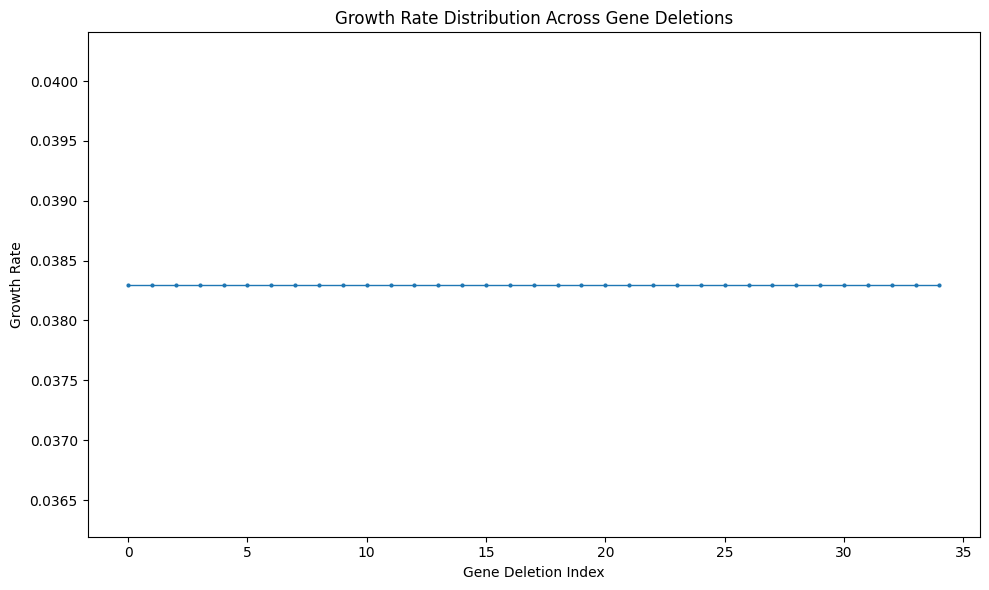

In [59]:
import matplotlib.pyplot as plt

growth_values = deletion_results['growth'].sort_values().reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(growth_values.index, growth_values.values, marker='o', markersize=2, linewidth=1)

ax.set_xlabel('Gene Deletion Index')
ax.set_ylabel('Growth Rate')
ax.set_title('Growth Rate Distribution Across Gene Deletions')


plt.tight_layout()
plt.show()

# Double gene deletion

In [8]:
gene_lists = ['AAFOLC_17895', 'AAFOLC_17905', 'AAFOLC_17910', 'AAFOLC_17900','AAFOLC_05725',
              'AAFOLC_21105', 'AAFOLC_10685','AAFOLC_05285', 'AAFOLC_05270',
              'AAFOLC_05280', 'AAFOLC_05290', 'AAFOLC_05260', 'AAFOLC_05295',
                'AAFOLC_05265', 'AAFOLC_05275', 'AAFOLC_05300', 'AAFOLC_05305',
                'AAFOLC_02505', 'AAFOLC_02510', 'AAFOLC_02515']
deletion_results = double_gene_deletion(
    model,
    gene_list1=gene_lists,
    gene_list2=gene_lists,
    method="fba",      # optional; default is "fba"
)

In [56]:
deletion_results.growth=deletion_results.growth.round(4)
deletion_results

,ids,growth,status
0,{NAD_H2},0.0383,optimal
1,"{HYD3pp, FERHYD}",0.0383,optimal
2,{CYTHYD},0.0383,optimal
3,"{HYD2, NAD_H2}",0.0383,optimal
4,"{HYD3pp, HADPCOADH}",0.0383,optimal
5,"{HADPCOADH, CYTHYD}",0.0383,optimal
6,"{FERHYD, HYD2pp}",0.0383,optimal
7,"{HYD3pp, HYD2pp}",0.0383,optimal
8,"{HYD2, FERHYD}",0.0383,optimal
9,{HADPCOADH},0.0383,optimal


In [ ]:
deletion_results.to_csv(file_path/'250807_double_gene_deletion_hyd_gem.csv')

# Double reaction deletion

In [62]:
reactionlist= ['NAD_H2','FERHYD','HADPCOADH','CYTHYD','HYD1pp','HYD2pp','HYD3pp','HYD2']
deletion_results = double_reaction_deletion(model,reaction_list1 =reactionlist,reaction_list2 =reactionlist)
deletion_results

,ids,growth,status
0,"{CYTHYD, HYD2pp}",0.038305,optimal
1,{HYD2},0.038305,optimal
2,"{HADPCOADH, FERHYD}",0.038305,optimal
3,{HYD3pp},0.038305,optimal
4,"{HYD2, HYD2pp}",0.038305,optimal
5,{FERHYD},0.038305,optimal
6,{HYD2pp},0.038305,optimal
7,"{HYD3pp, CYTHYD}",0.038305,optimal
8,"{HYD3pp, HYD2}",0.038305,optimal
9,"{CYTHYD, NAD_H2}",0.038305,optimal


Bar plot gene deletion

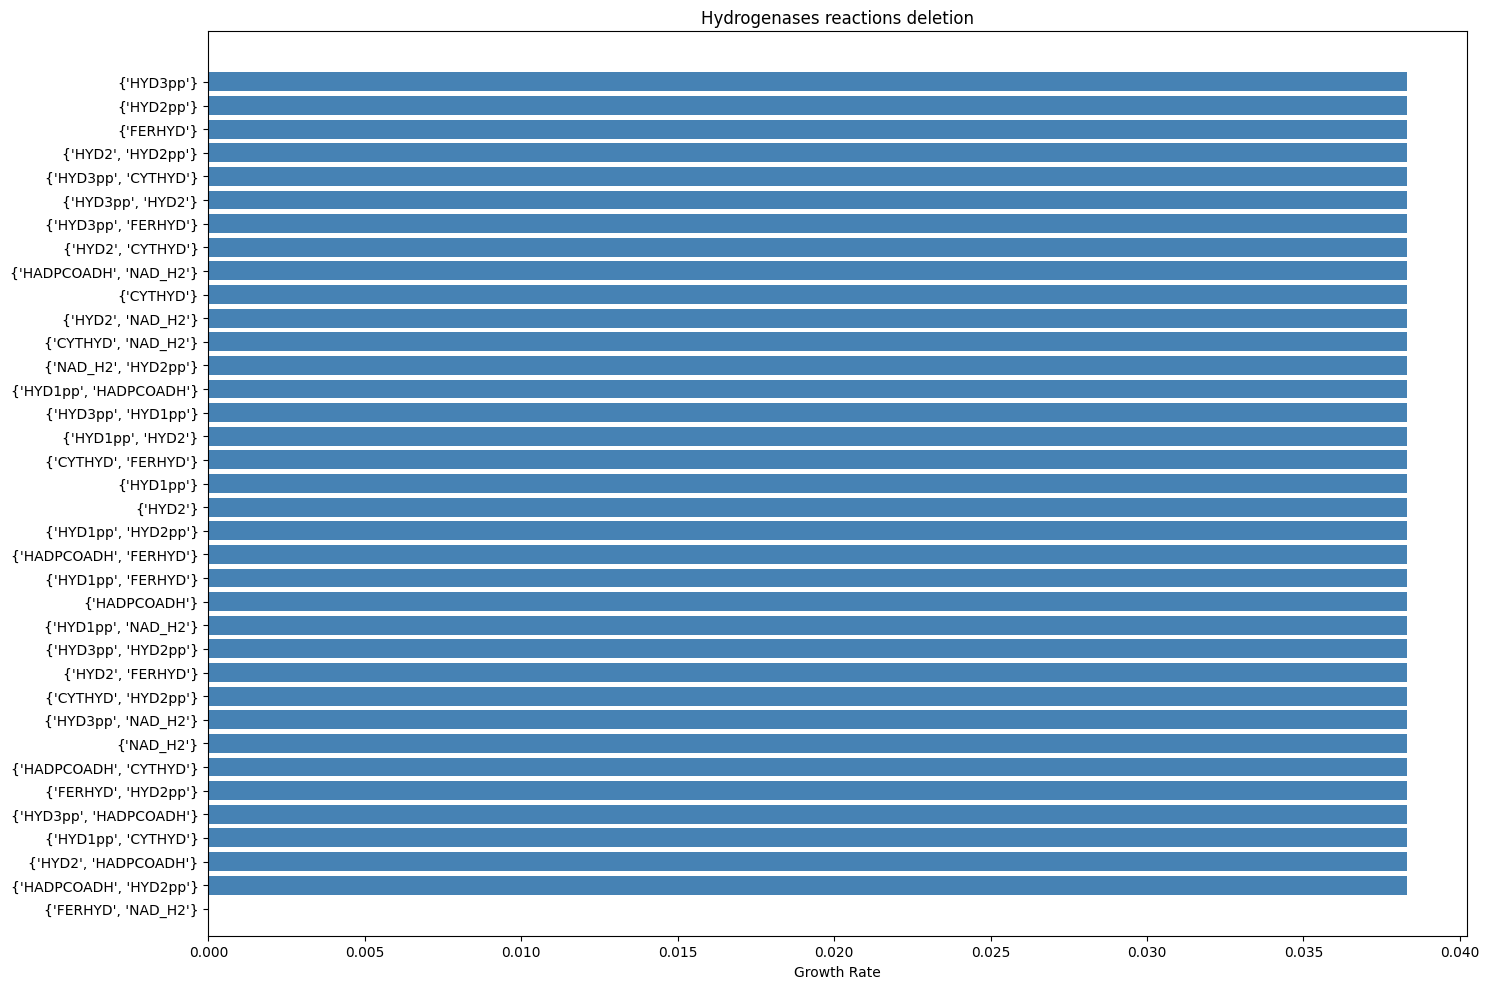

In [78]:
import matplotlib.pyplot as plt
# Plot the bar chart
# Ensure all labels are strings and fill missing ones
deletion_results['ids'] = deletion_results['ids'].fillna("unknown").astype(str)

# Optional: sort by lowest growth
deletion_results_sorted = deletion_results.sort_values(by='growth').head(70)

# Plot the bar chart
plt.figure(figsize=(15, 10))
plt.barh(deletion_results_sorted['ids'], deletion_results_sorted['growth'], color='steelblue')
plt.xlabel("Growth Rate")
plt.title("Hydrogenases reactions deletion")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create a list of all reactions

In [ ]:
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model" 
file_path = base_dir / "reaction_list.xlsx"
ju.export_reactions_to_excel(model, file_path)

# Create a list of all metabolites

In [ ]:
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model" 
file_path = base_dir / "metabolites_list.xlsx"
ju.export_metabolites_to_excel(model, file_path)

# Create a list of all metabolites in a reaction

In [ ]:
reaction_id = 'Growth'
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model" 
file_path = base_dir / f"metabolites_{reaction_id}_list.xlsx"
ju.export_metabolites_from_reaction(model, reaction_id, file_path)

# Calculate product yield

add a sink reaction for targeted product

In [ ]:
model.add_boundary(model.metabolites.get_by_id('hdca_c'), type='sink',lb=0.0, ub=1000)

change the substrat intake

In [ ]:
reaction = model.reactions.get_by_id('EX_glc__D_e')
reaction.bounds = -10.0, 0.0

calculate the yield (g/g)

In [ ]:
model.objective='SK_hdca_c'
model.optimize()


product_flux =  model.reactions.get_by_id('SK_hdca_c').flux
substrat_flux = - model.reactions.get_by_id('EX_glc__D_e').flux
product_MM = 280.45
substrat_MM = 180.156

yield_g_g = (product_flux * product_MM)/(substrat_flux*substrat_MM)
yield_g_g